<a href="https://colab.research.google.com/github/Karsuman4298/Generative-AI/blob/main/nanoVLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch,math,random
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from PIL import Image,ImageDraw
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [2]:
IMG_SIZE=32
EMBED_DIM=64
ATTENTION_HEAD=4
BATCH_SIZE=12
EPOCH=10
LR=3e-4
TEMPERATURE=0.08
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')




# SYNTHETIC DATASET

In [3]:
color=['red','green','blue','yellow','purple','orange','pink','brown','grey']
shapes=['square','circle','rectangle']
positions=['left','center','right','top','bottom','top-left','top-right','bottom-left','bottom-right']

# DRAWING IMAGE SHAPES

In [4]:

def draw_sample(color, position, shape, img_size=IMG_SIZE):
  img=Image.new('RGB',(img_size,img_size),'white')
  draw=ImageDraw.Draw(img)
  margin=6
  h=w=img_size-2*margin

  # Calculate x coordinates
  if 'left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'top-left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'bottom-left' in position:
      x0 = margin
      x1 = margin + w // 2
  elif 'right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  elif 'top-right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  elif 'bottom-right' in position:
      x0 = margin + w // 2
      x1 = img_size - margin
  else: # center or vertical positions
      x0 = margin + w // 4
      x1 = margin + 3 * w // 4

  # Calculate y coordinates
  if 'top' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'top-left' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'top-right' in position:
      y0 = margin
      y1 = margin + h // 2
  elif 'bottom' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  elif 'bottom-left' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  elif 'bottom-right' in position:
      y0 = margin + h // 2
      y1 = img_size - margin
  else: # center or horizontal positions
      y0 = margin + h // 4
      y1 = margin + 3 * h // 4

  if shape == 'square':
      draw.rectangle([x0, y0, x1, y1], fill=color, outline='black')
  elif shape == 'circle':
      draw.ellipse([x0, y0, x1, y1], fill=color, outline='black')
  else: # triangle
      draw.polygon([(x0 + (x1 - x0) // 2, y0), (x0, y1), (x1, y1)], fill=color, outline='black')
  return img

In [5]:
class ShapeDataset:
    def __init__(self, image_size=64):
        self.image = []
        self.captions = []
        self.image_size = image_size

        for c in color:          # Fixed: changed 'colors' to 'color'
            for p in positions:
                for s in shapes:
                    img_np = draw_sample(c, p, s, img_size=image_size)
                    # Convert to tensor (CHW, normalized to [0,1])
                    img_tensor = (
                        torch.from_numpy(np.asarray(img_np))
                        .permute(2, 0, 1)      # HWC → CHW
                        .float() / 255.0       # ← fixed: / instead of //
                    )
                    self.image.append(img_tensor)
                    self.captions.append(f"{c} {s} {p}")

        # Build vocabulary
        self.vocab, self.word2idx = self.build_vocab(self.captions)

    def build_vocab(self, texts):
        words = sorted({word for text in texts for word in text.split()})
        vocab = ['[CLS]'] + words
        w2i = {w: i for i, w in enumerate(vocab)}
        return vocab, w2i

    def encode_text(self, text):
        toks = [self.word2idx['[CLS]']] + [self.word2idx[word] for word in text.split()]
        return torch.tensor(toks, dtype=torch.long)

    def __len__(self):
        return len(self.image)

    def __getitem__(self, idx):
        return self.image[idx], self.encode_text(self.captions[idx])

In [6]:
full_ds=ShapeDataset()
VOCAB_SIZE=len(full_ds.vocab)
print(VOCAB_SIZE)
print(full_ds.vocab)
print(full_ds.captions)


22
['[CLS]', 'blue', 'bottom', 'bottom-left', 'bottom-right', 'brown', 'center', 'circle', 'green', 'grey', 'left', 'orange', 'pink', 'purple', 'rectangle', 'red', 'right', 'square', 'top', 'top-left', 'top-right', 'yellow']
['red square left', 'red circle left', 'red rectangle left', 'red square center', 'red circle center', 'red rectangle center', 'red square right', 'red circle right', 'red rectangle right', 'red square top', 'red circle top', 'red rectangle top', 'red square bottom', 'red circle bottom', 'red rectangle bottom', 'red square top-left', 'red circle top-left', 'red rectangle top-left', 'red square top-right', 'red circle top-right', 'red rectangle top-right', 'red square bottom-left', 'red circle bottom-left', 'red rectangle bottom-left', 'red square bottom-right', 'red circle bottom-right', 'red rectangle bottom-right', 'green square left', 'green circle left', 'green rectangle left', 'green square center', 'green circle center', 'green rectangle center', 'green squar

/tmp/ipykernel_973/3620352882.py:13: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  torch.from_numpy(np.asarray(img_np))


# Train - val

In [7]:
train_size=int(0.8 * len(full_ds))
val_size=len(full_ds) - train_size
train_ds,val_ds=torch.utils.data.random_split(full_ds,[train_size,val_size])

In [8]:
train_size,val_size

(194, 49)

In [9]:
train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)

# Sample datapoint


brown brown rectangle top-left


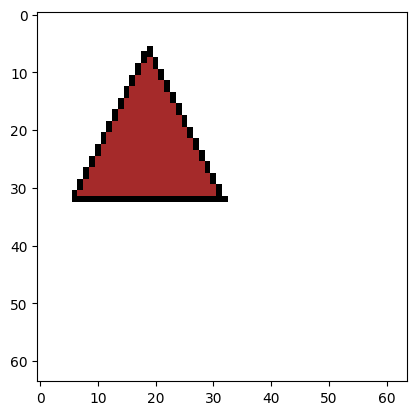

In [10]:
img_batch, caps_batch = next(iter(train_loader))
idx = random.randint(0, len(img_batch) - 1)
plt.imshow(img_batch[idx].permute(1, 2, 0))
print(full_ds.vocab[caps_batch[idx][1]], ' '.join([full_ds.vocab[i.item()] for i in caps_batch[idx][1:]]))

# Image Encoder

In [11]:
class ImageEncoder(nn.Module):
    def __init__(self,EMBED_DIM):
        super().__init__()
        self.convolutions=nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,128,kernel_size=3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,256,kernel_size=3,stride=2,padding=1),
            nn.ReLU()
        )

        self.projection=nn.Linear(256,EMBED_DIM)
        self.layer_norm=nn.LayerNorm(EMBED_DIM)

    def forward(self,x):
      x=self.convolutions(x)
      x=x.mean(dim=[2,3])
      x=self.projection(x)
      x=F.normalize(self.layer_norm(x),dim=-1) # Fixed typo
      return x

# Text Encoder



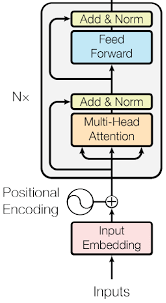

In [1]:

class TextEncoder(nn.Module):
  def __init__(self,embed_dim=EMBED_DIM,num_heads=ATTENTION_HEAD,vocab_size=VOCAB_SIZE,context_window=4):
    super().__init__()
    self.token_embedding=nn.Embedding(vocab_size,embed_dim)
    self.position_embedding=nn.Embedding(context_window,embed_dim)
    self.multihead_attention=nn.MultiheadAttention(embed_dim,num_heads)
    self.norm=nn.LayerNorm(embed_dim)
    self.Linear=nn.Linear(embed_dim,embed_dim)
    self.norm=nn.LayerNorm(embed_dim)



  def forward(self,toks):
    toks.shape=5


NameError: name 'nn' is not defined